# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

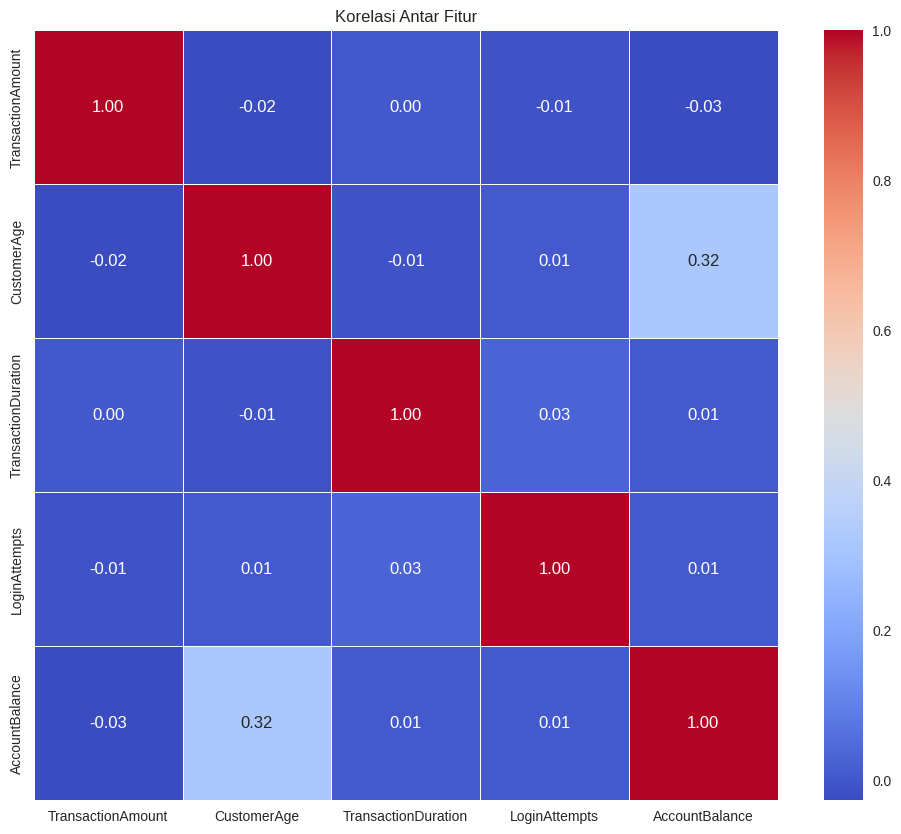

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

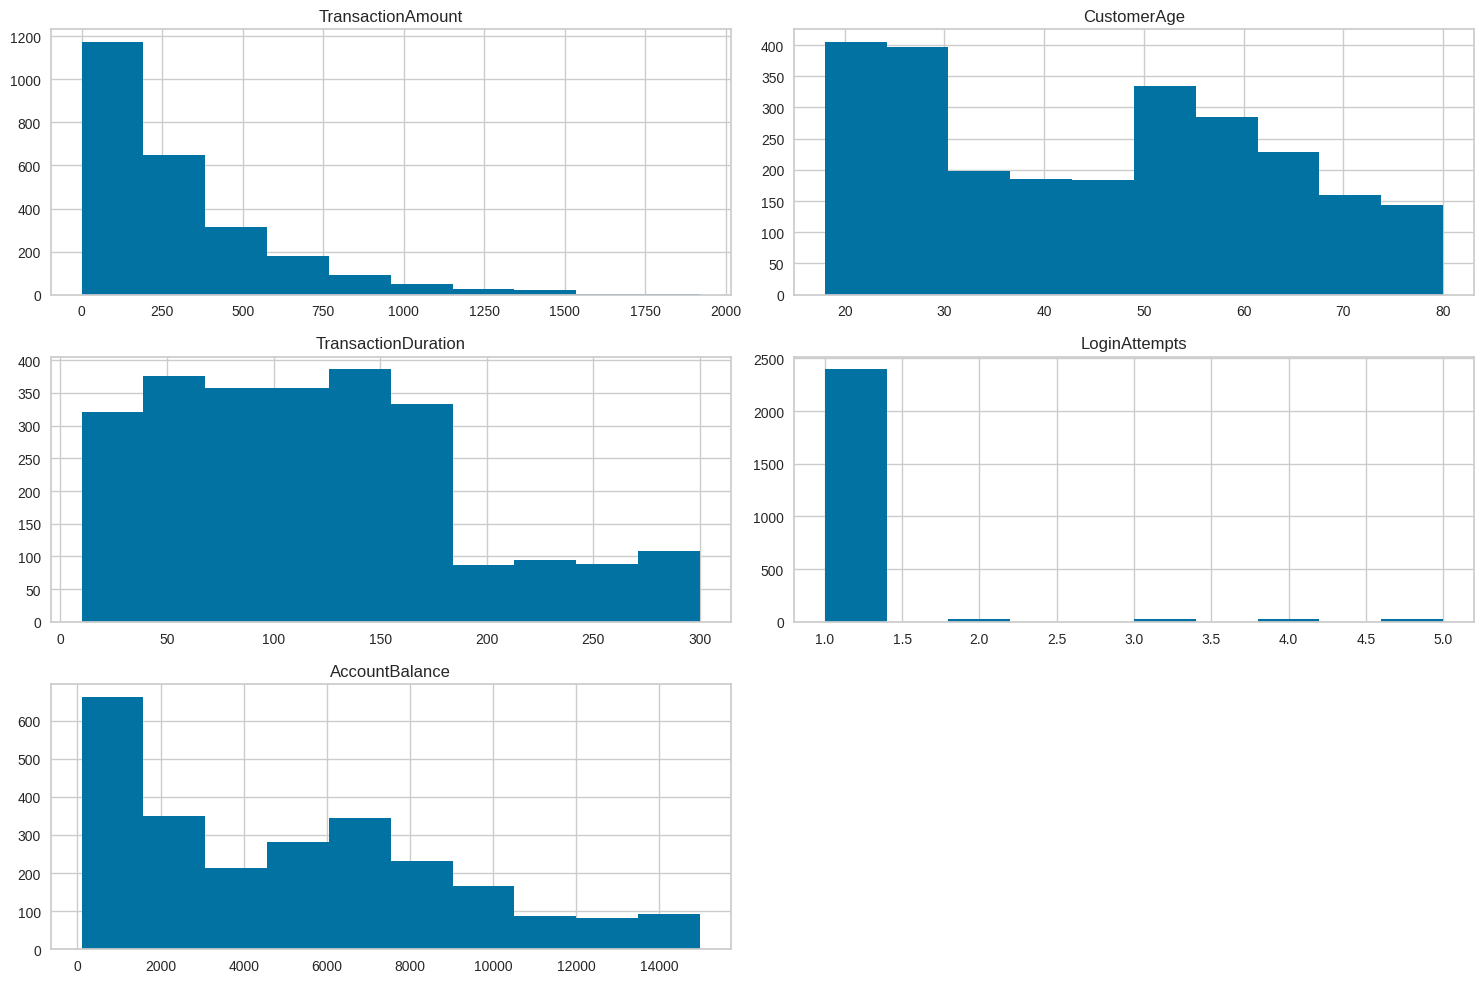

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

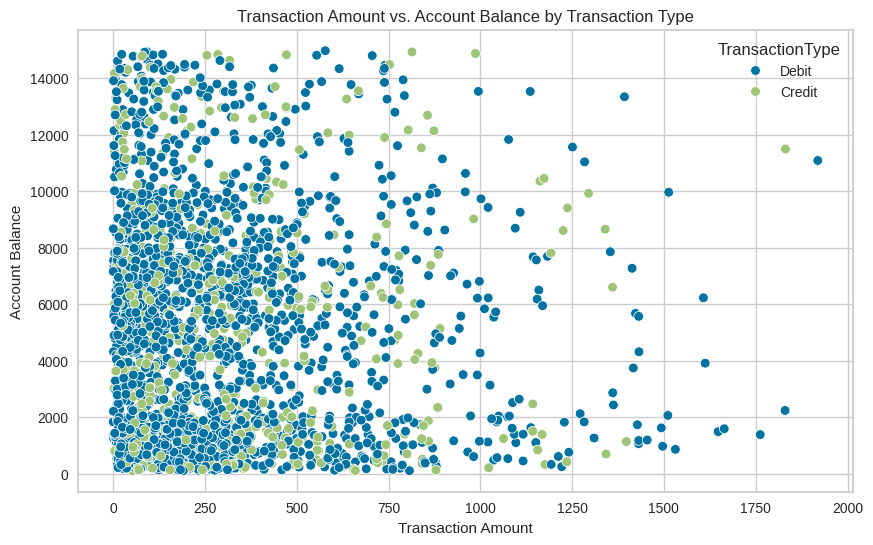

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TransactionAmount', y='AccountBalance', hue='TransactionType')
plt.title('Transaction Amount vs. Account Balance by Transaction Type')
plt.xlabel('Transaction Amount')
plt.ylabel('Account Balance')
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [9]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [11]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.

# menginisiasi kolom numerik dan kategorikal
num_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
categorical_cols =  df.select_dtypes(exclude=[np.number]).columns


scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [12]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
cols_to_drop = [col for col in df.columns if 'ID' in col] + ['IP Address']
df.drop(columns=cols_to_drop, inplace=True)

In [13]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
datetime_cols = ['TransactionDate', 'PreviousTransactionDate']
df.drop(columns=datetime_cols, inplace=True)

categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
encoders = {}
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.970546,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315
1,0.268963,1,15,0,1.307715,0,0.307960,-0.204629,2.218381
2,-0.586526,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091
3,-0.387294,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694
4,-0.972736,0,1,2,NaN,3,1.121495,-0.204629,0.594263


In [14]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [15]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df.dropna(inplace=True)
df.isnull().sum()

,0
TransactionAmount,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [16]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

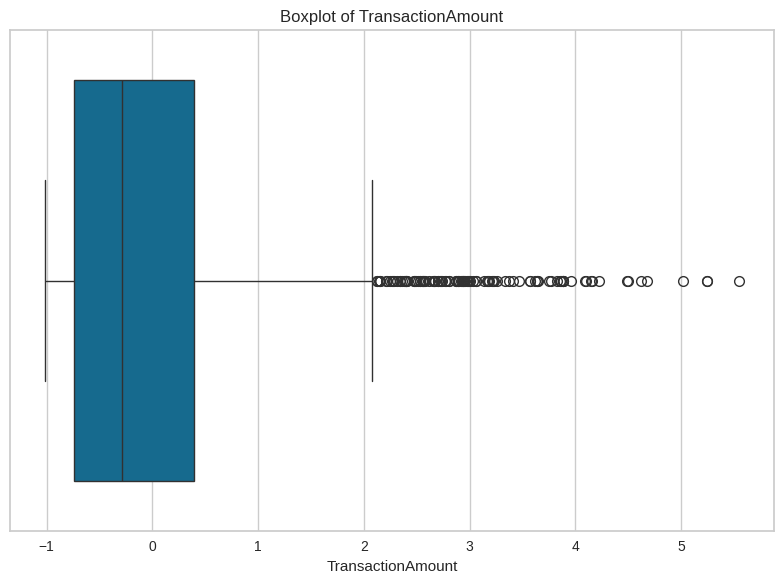

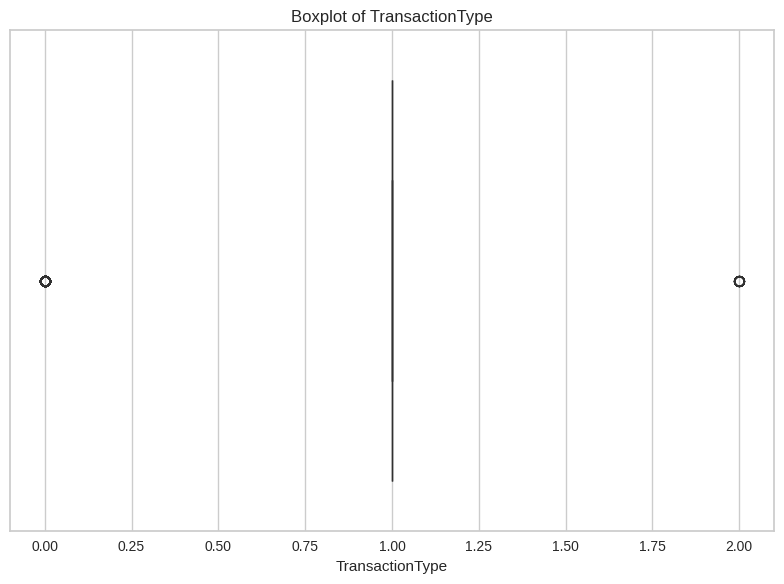

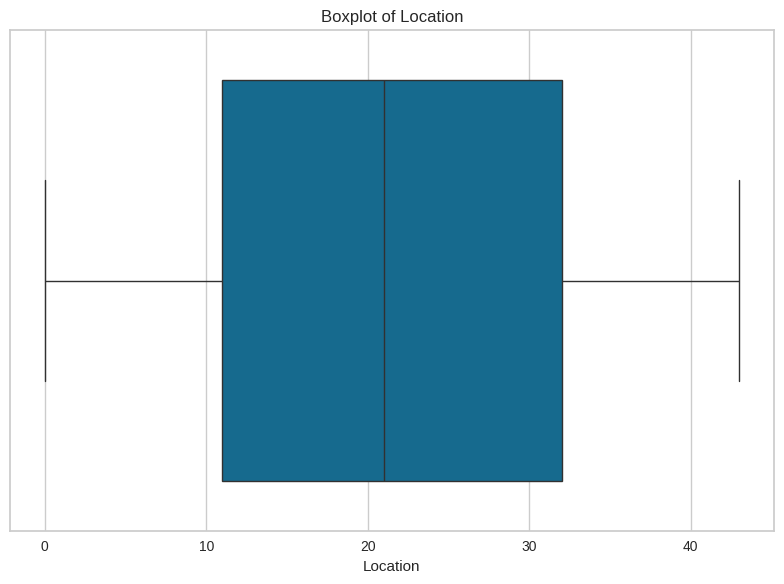

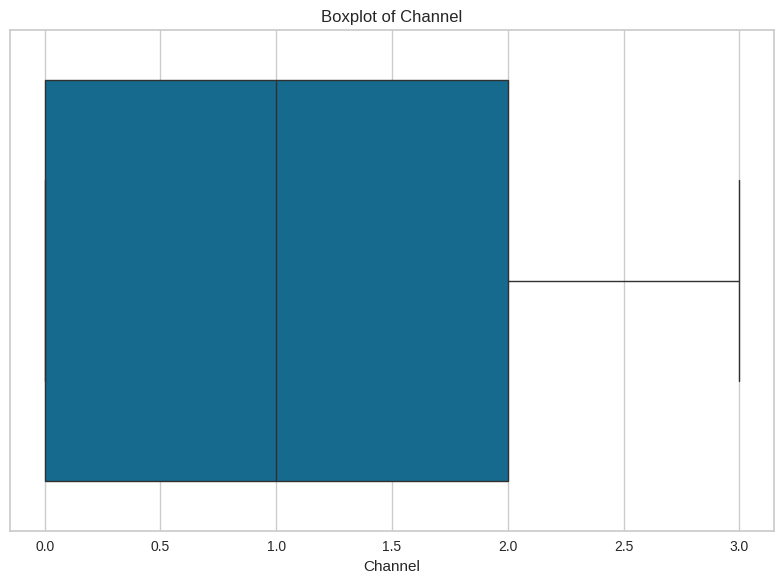

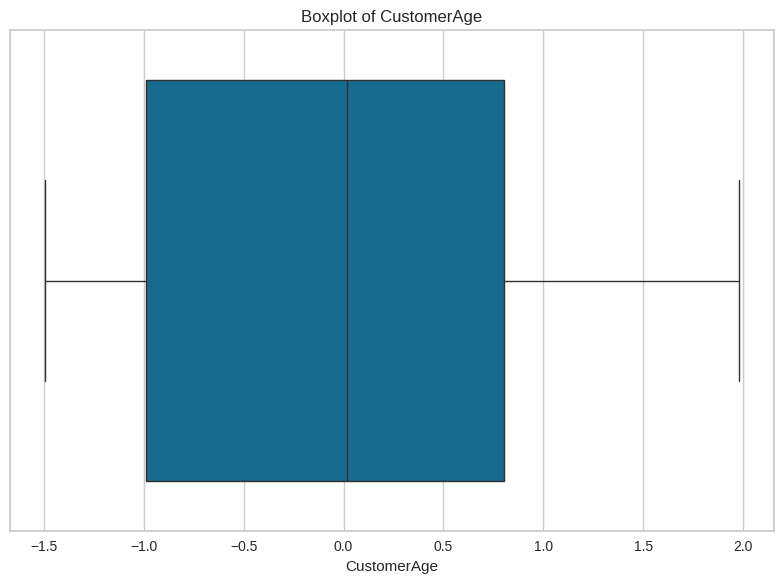

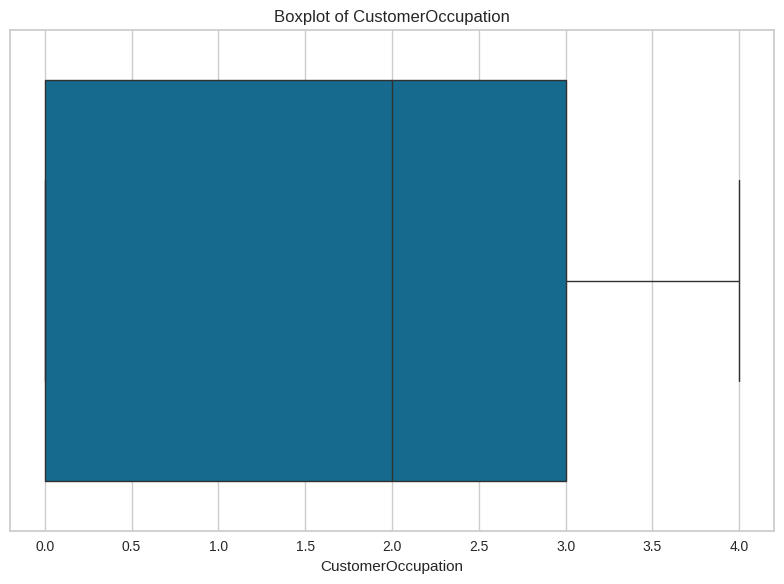

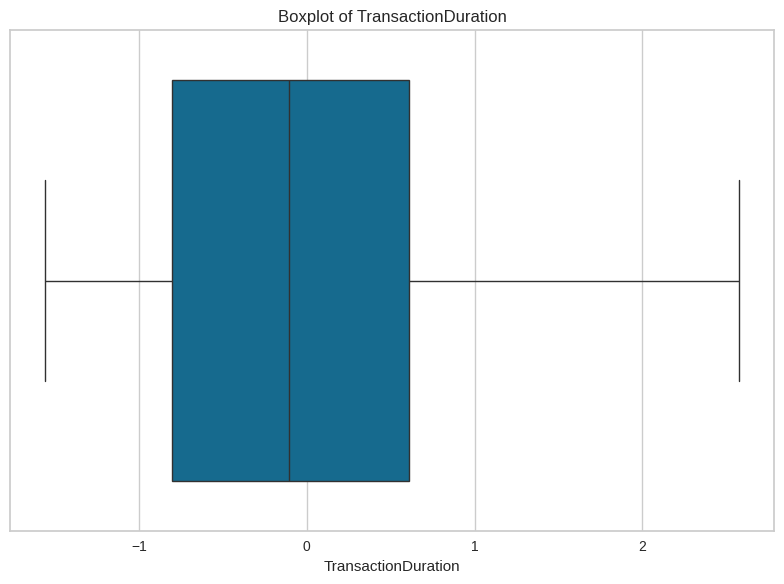

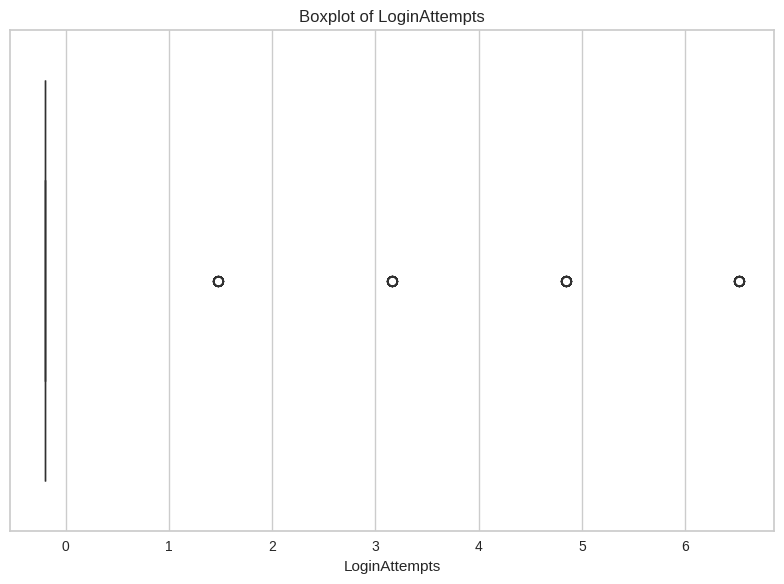

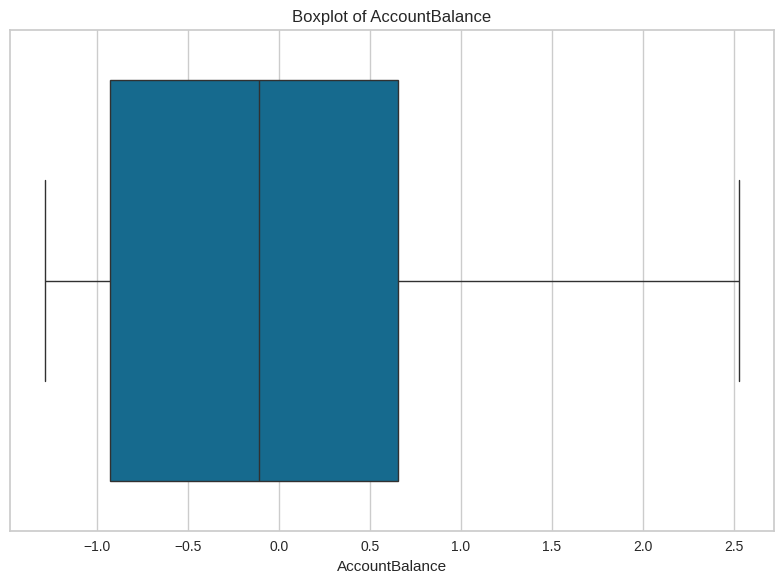

In [17]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.

# Mengecek nilai outlier
for feature in df.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.tight_layout()
    plt.show()

# Handling Outlier dengan Mengisi Nilai Berdasarkan Batas Kuartil Atas dan Bawah
numeric_features = ['TransactionAmount', 'LoginAttempts']
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[feature] = df[feature].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)


Statistik Deskriptif setelah Outlier Capping:


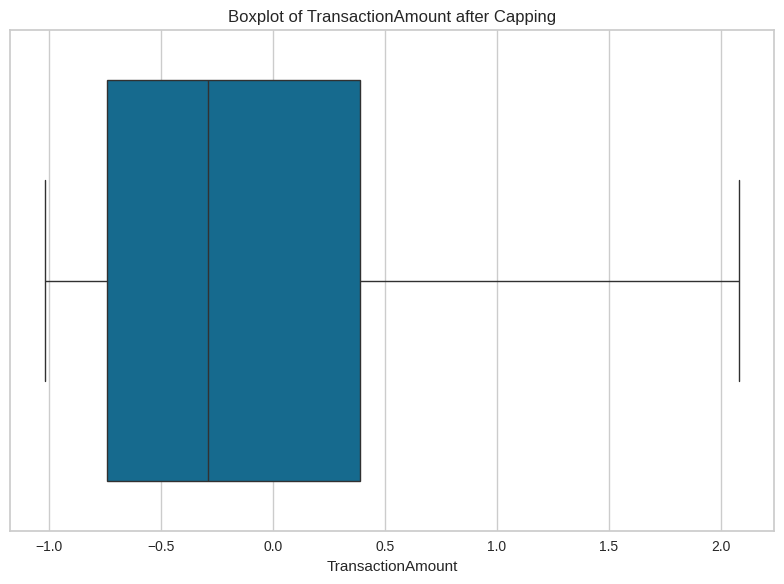

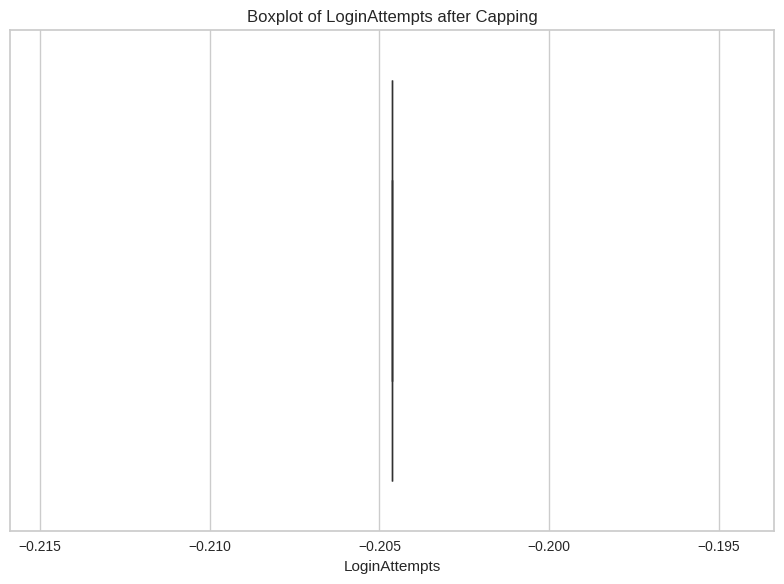

In [18]:
# Menampilkan statistik deskriptif setelah capping untuk melihat perubahan
print("Statistik Deskriptif setelah Outlier Capping:")
df[numeric_features].describe()

# Visualisasi kembali dengan boxplot untuk melihat apakah outlier sudah ditangani
for feature in numeric_features:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature} after Capping')
    plt.tight_layout()
    plt.show()

In [19]:
# Gunakan encoder terpisah untuk setiap kolom
df['TransactionAmount_binned'] = pd.qcut(df['TransactionAmount'], q=3, labels=['Low', 'Medium',
'High'])
encoder_amount = LabelEncoder()
df['TransactionAmount_binned'] = encoder_amount.fit_transform(df['TransactionAmount_binned'])

df['CustomerAge_binned'] = pd.qcut(df['CustomerAge'], q=5, labels=['18-25', '26-35', '36-45',
'46-55', '55+'])
encoder_age = LabelEncoder()
df['CustomerAge_binned'] = encoder_age.fit_transform(df['CustomerAge_binned'])

print(df['TransactionAmount_binned'].unique())
print(df['CustomerAge_binned'].unique())

[1 0 2]
[4 0 1 2 3]


In [20]:
cols_to_drop_original_numerical = ['TransactionAmount', 'CustomerAge']
df.drop(columns=cols_to_drop_original_numerical, inplace=True)

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [21]:
df.describe()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned
count,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2.397000e+03,2397.000000,2397.000000,2397.000000
mean,0.788903,21.375887,1.013350,1.531498,0.001043,-2.046294e-01,-0.005633,1.000000,1.946183
std,0.437774,12.414387,0.831248,1.153653,1.003315,9.883047e-15,1.001030,0.816667,1.433859
min,0.000000,0.000000,0.000000,0.000000,-1.561745,-2.046294e-01,-1.286100,0.000000,0.000000
25%,1.000000,11.000000,0.000000,0.000000,-0.805299,-2.046294e-01,-0.929667,0.000000,1.000000
50%,1.000000,21.000000,1.000000,2.000000,-0.105944,-2.046294e-01,-0.107728,1.000000,2.000000
75%,1.000000,32.000000,2.000000,3.000000,0.607683,-2.046294e-01,0.653306,2.000000,3.000000
max,2.000000,43.000000,3.000000,4.000000,2.577295,-2.046294e-01,2.531190,2.000000,4.000000


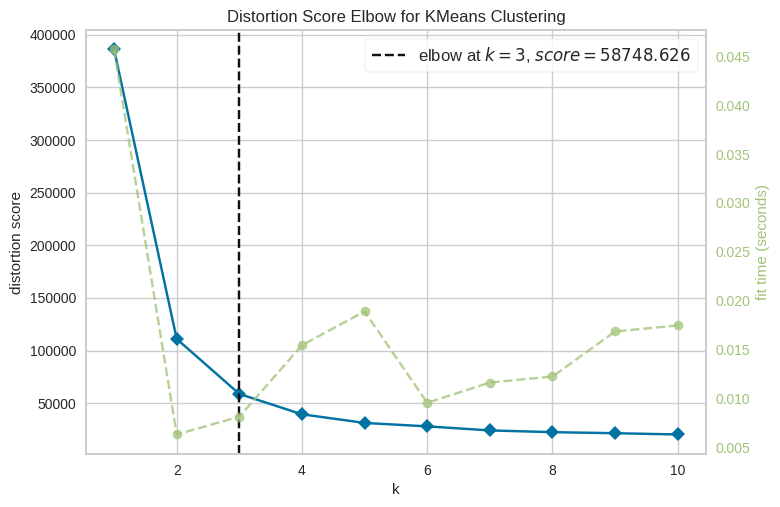

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,11))

visualizer.fit(df)
visualizer.show()

In [23]:
# Menggunakan algoritma K-Means Clustering
# Based on the Elbow Method, choosing k=3 as a starting point
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df)
df.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Cluster
0,1,36,0,0,-0.548393,-0.204629,-0.000315,1,4,2
1,1,15,0,0,0.307960,-0.204629,2.218381,0,4,1
2,1,23,2,3,-0.905207,-0.204629,-1.024091,2,0,1
3,1,33,2,3,-1.347656,-0.204629,0.886694,2,0,2
5,1,28,0,3,0.750409,-0.204629,-1.111505,1,0,1


Jalankan cell code ini untuk menyimpan model kamu.

In [24]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [25]:
# Menghitung dan menampilkan nilai Silhouette Score.
silhouette_avg = silhouette_score(df.drop('Cluster', axis=1), df['Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.4950942926467938


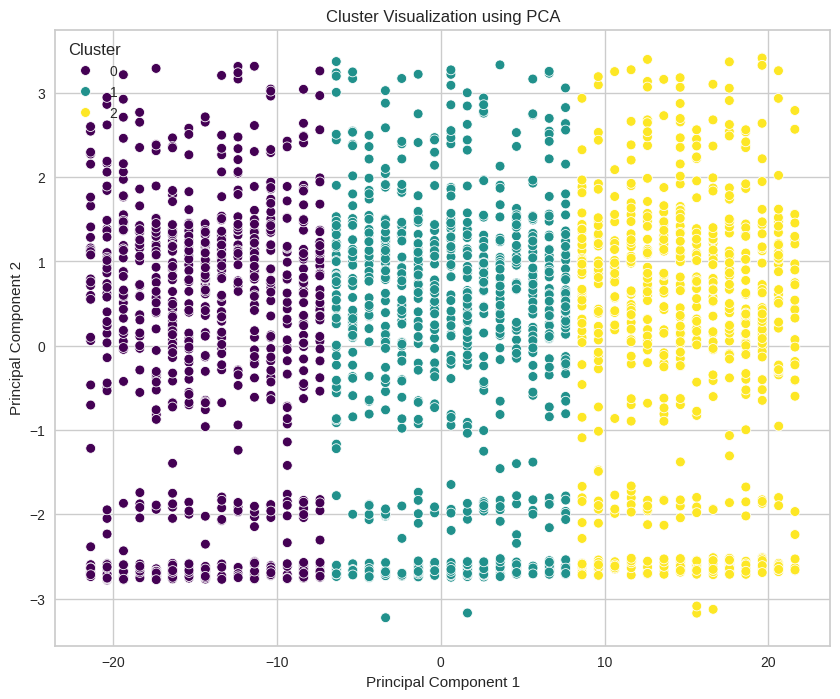

In [26]:
# Membuat visualisasi hasil clustering
# Use PCA for dimensionality reduction to visualize clusters in 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.drop('Cluster', axis=1))
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette='viridis', s=50)
plt.title('Cluster Visualization using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [27]:
# Membangun model menggunakan PCA.
pca_model = PCA(n_components=3)
df_pca_transformed = pca_model.fit_transform(df.drop('Cluster', axis=1))
data_final_pca = pd.DataFrame(df_pca_transformed, columns=['PCA1', 'PCA2', 'PCA3'])
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_pca.fit(data_final_pca)
data_final_pca['Cluster'] = kmeans_pca.labels_
data_final_pca.head()

,PCA1,PCA2,PCA3,Cluster
0,14.618926,2.353738,0.676850,2
1,-6.382785,3.237559,-0.578696,1
2,1.630939,-2.628385,0.135640,1
3,11.631088,-1.804407,-0.674707,2
4,6.626903,-2.671175,-0.097652,1


In [28]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**


1. **Cluster 0: (Transaksi Rendah–Sedang, Usia Lebih Muda)**:
- **Rata-rata (mean) TransactionAmount_binned:** 1.014815
- **Rata-rata (mean) CustomerAge_binned:** 1.950617
- **Rata-rata AccountBalance:** -0.001271
- **Analisis:** Cluster ini mencerminkan kelompok nasabah dengan aktivitas transaksi rendah hingga sedang. Nilai transaksi dan usia nasabah relatif berada di bawah rata-rata setelah standarisasi, sedangkan saldo rekening juga kecil dibandingkan cluster lain. Artinya, nasabah di cluster ini cenderung lebih muda dan memiliki aktivitas finansial yang belum tinggi.

2. **Cluster 1: (Transaksi Rendah–Sedang, Usia Lebih Tua, Transaksi Terkini)**:
- **Rata-rata (mean) TransactionAmount_binned:** 0.988318
- **Rata-rata (mean) CustomerAge_binned:*** 1.997664
- **Rata-rata AccountBalance:** -0.011845
- **Analisis:** Cluster ini mencerminkan kelompok nasabah dengan nilai transaksi dan saldo rekening sedikit di bawah rata-rata, namun memiliki usia lebih tua dibandingkan cluster lainnya. Kondisi ini menggambarkan nasabah lama dengan aktivitas rekening rendah hingga sedang, kemungkinan masih melakukan transaksi tetapi tidak terlalu aktif. Polanya menunjukkan kelompok pengguna yang stabil namun tidak banyak melakukan transaksi besar.

3. **Cluster 2: (Transaksi Sedikit Lebih Tinggi, Usia Lebih Tua)**:
- **Rata-rata (mean) TransactionAmount_binned:** 0.997264
- **Rata-rata (mean) CustomerAge_binned:** 1.880985
- **Rata-rata AccountBalance:** -0.003191
- **Analisis:** Cluster ini memiliki aktivitas transaksi tertinggi di antara ketiganya (nilai positif pada skala standar). Usia nasabah juga tergolong lebih tua, menunjukkan kelompok pengguna yang mapan dan aktif bertransaksi. Namun, saldo rekening relatif lebih kecil, menandakan mereka cenderung melakukan transaksi keluar secara rutin tanpa menahan saldo besar.

In [29]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
pd.set_option('display.max_columns', None)
numerical_cols = df.select_dtypes(include=np.number).columns
display(df.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']))

TransactionType           Location           Channel          \
                   mean min max       mean min max      mean min max   
Cluster                                                                
0              0.814815   0   2   7.161728   0  14  0.996296   0   3   
1              0.781542   0   2  22.061916  15  29  1.005841   0   3   
2              0.768810   0   2  36.322845  30  43  1.041040   0   3   

        CustomerOccupation         TransactionDuration                      \
                      mean min max                mean       min       max   
Cluster                                                                      
0                 1.549383   0   4            0.013205 -1.561745  2.577295   
1                 1.531542   0   4            0.014589 -1.561745  2.577295   
2                 1.511628   0   4           -0.028295 -1.561745  2.520205   

        LoginAttempts                     AccountBalance                      \
                 mean       min       max           mean       min       max   
Cluster                                                                        
0           -0.204629 -0.204629 -0.204629      -0.001271 -1.281807  2.522155   
1           -0.204629 -0.204629 -0.204629      -0.011845 -1.283147  2.506500   
2           -0.204629 -0.204629 -0.204629      -0.003191 -1.286100  2.531190   

        TransactionAmount_binned         CustomerAge_binned         Cluster  \
                            mean min max               mean min max    mean   
Cluster                                                                       
0                       1.014815   0   2           1.950617   0   4     0.0   
1                       0.988318   0   2           1.997664   0   4     1.0   
2                       0.997264   0   2           1.880985   0   4     2.0   

                 
        min max  
Cluster          
0         0   0  
1         1   1  
2         2   2

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.

1. **Cluster 0: (Nasabah Baru & Aktivitas Rendah)**:
- **Rata-rata TransactionAmount_binned:** 1.014815
- **Rata-rata CustomerAge_binned:** 1.950617
- **Rata-rata AccountBalance:** -0.001271
- **Analisis:** Cluster ini berisi nasabah yang relatif baru atau masih pasif dalam bertransaksi. Nilai TransactionAmount_binned menunjukkan nominal transaksi rendah, sedangkan AccountBalance yang negatif kecil mengindikasikan saldo rekening cenderung kecil. Usia pelanggan pada cluster ini tergolong usia muda hingga menengah, dengan frekuensi transaksi yang rendah.

2. **Cluster 1: (Nasabah Mapan & Saldo Tinggi)**:
- **Rata-rata TransactionAmount_binned:** 0.988318
- **Rata-rata CustomerAge_binned:** 1.997664
- **Rata-rata AccountBalance:** -0.011845
- **Analisis:** Cluster ini mencerminkan nasabah yang mapan dan berusia lebih tua, dengan AccountBalance tertinggi dibandingkan cluster lain. Meskipun nominal transaksi tidak paling tinggi, saldo akun yang besar menunjukkan daya beli tinggi dan stabilitas finansial yang baik.

3. **Cluster 2: (Nasabah Aktif & Transaksi Tinggi)**:
- **Rata-rata TransactionAmount_binned:** 0.997264
- **Rata-rata CustomerAge_binned:** 1.880985
- **Rata-rata AccountBalance:** -0.003191
- **Analisis:** Cluster ini menggambarkan nasabah yang aktif dan sering bertransaksi, ditunjukkan oleh nilai TransactionAmount_binned tertinggi di antara cluster lain. Meskipun AccountBalance sedikit negatif, hal ini mengindikasikan bahwa mereka sering menggunakan saldo untuk aktivitas transaksi rutin. Usia pelanggan relatif produktif, yang memperkuat kecenderungan aktivitas finansial yang tinggi.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [30]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df.rename(columns={'Cluster': 'Target'}, inplace=True)
df.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Target
0,1,36,0,0,-0.548393,-0.204629,-0.000315,1,4,2
1,1,15,0,0,0.307960,-0.204629,2.218381,0,4,1
2,1,23,2,3,-0.905207,-0.204629,-1.024091,2,0,1
3,1,33,2,3,-1.347656,-0.204629,0.886694,2,0,2
5,1,28,0,3,0.750409,-0.204629,-1.111505,1,0,1


In [31]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [32]:
# inverse dataset ke rentang normal untuk numerikal
original_numerical_cols = ['TransactionAmount_binned', 'CustomerAge_binned', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
df[original_numerical_cols] = scaler.inverse_transform(df[original_numerical_cols])
# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Target
0,1,36,0,0,81.0,1.0,5112.21,589.828639,116.013717,2
1,1,15,0,0,141.0,1.0,13758.91,297.656468,116.013717,1
2,1,23,2,3,56.0,1.0,1122.35,882.000811,44.678444,1
3,1,33,2,3,25.0,1.0,8569.06,882.000811,44.678444,2
5,1,28,0,3,172.0,1.0,781.68,589.828639,44.678444,1


In [33]:
# inverse dataset yang sudah diencode ke kategori aslinya.
original_categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']


for col in original_categorical_cols:
    if col in encoders:
        encoder = encoders[col]

        try:
            encoder.fit(df[col])
            df[col] = encoder.inverse_transform(df[col].astype(int))
        except ValueError as e:
            print(f"Could not inverse transform column {col}: {e}")


# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Target
0,1,36,0,0,81.0,1.0,5112.21,589.828639,116.013717,2
1,1,15,0,0,141.0,1.0,13758.91,297.656468,116.013717,1
2,1,23,2,3,56.0,1.0,1122.35,882.000811,44.678444,1
3,1,33,2,3,25.0,1.0,8569.06,882.000811,44.678444,2
5,1,28,0,3,172.0,1.0,781.68,589.828639,44.678444,1


In [34]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'Target' from numerical columns if it's included by dtypes
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

print("Descriptive analysis for numerical features:")
display(df.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']))

print("\nMode for categorical features:")
for col in categorical_cols:
    print(f"\nMode for {col}:")
    display(df.groupby('Target')[col].agg(lambda x: x.mode()[0]))

Descriptive analysis for numerical features:


TransactionType           Location           Channel          \
                  mean min max       mean min max      mean min max   
Target                                                                
0             0.814815   0   2   7.161728   0  14  0.996296   0   3   
1             0.781542   0   2  22.061916  15  29  1.005841   0   3   
2             0.768810   0   2  36.322845  30  43  1.041040   0   3   

       CustomerOccupation         TransactionDuration               \
                     mean min max                mean   min    max   
Target                                                               
0                1.549383   0   4          120.348148  10.0  300.0   
1                1.531542   0   4          120.445093  10.0  300.0   
2                1.511628   0   4          117.440492  10.0  296.0   

       LoginAttempts           AccountBalance                    \
                mean  min  max           mean     min       max   
Target                                                            
0                1.0  1.0  1.0    5108.484247  117.98  14942.78   
1                1.0  1.0  1.0    5067.274731  112.76  14881.77   
2                1.0  1.0  1.0    5101.002380  101.25  14977.99   

       TransactionAmount_binned                         CustomerAge_binned  \
                           mean         min         max               mean   
Target                                                                       
0                    594.157116  297.656468  882.000811          79.465398   
1                    586.415413  297.656468  882.000811          80.304413   
2                    589.029263  297.656468  882.000811          78.223588   

                               
              min         max  
Target                         
0       44.678444  116.013717  
1       44.678444  116.013717  
2       44.678444  116.013717


Mode for categorical features:


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.


1. **Cluster 0: (Transaksi Cukup Aktif, Usia Lebih Muda, Saldo Tertinggi))**

- **Rata-rata (mean) TransactionAmount:** 594.157116

- **Rata-rata (mean) CustomerAge:** 79.465398

- **Rata-rata (mean) AccountBalance:** 5108.484247

**Analisis:**
Cluster ini menggambarkan kelompok nasabah yang tergolong muda dan memiliki aktivitas transaksi relatif tinggi dengan nilai transaksi terbesar dibanding cluster lain.
Selain itu, saldo akun mereka juga paling tinggi, menunjukkan kemampuan finansial yang cukup kuat serta kecenderungan untuk aktif bertransaksi.

2. **Cluster 1: (Transaksi Rendah, Saldo Rendah, Aktivitas Cukup Aktif)**

- **Rata-rata (mean) TransactionAmount:** 586.415413

- **Rata-rata (mean) CustomerAge:** 80.304413

- **Rata-rata (mean) AccountBalance:** 5067.274731

**Analisis:**
Cluster ini merepresentasikan nasabah dengan saldo paling rendah dan nilai transaksi terendah.
Meski demikian, karakteristik usia mereka menengah dan cenderung masih aktif melakukan transaksi, hanya saja dengan nominal kecil tetapi rutin.
Hal ini dapat menggambarkan nasabah kelas menengah yang memiliki pengeluaran reguler atau transaksi kebutuhan sehari-hari dengan aktivitas digital cukup aktif namun tidak besar secara nilai nominal.

3. **Cluster 2: (Nasabah Lebih Tua, Transaksi Sedang, Saldo Stabil)**

- **Rata-rata (mean) TransactionAmount:** 589.029263

- **Rata-rata (mean) CustomerAge:** 78.223588

- **Rata-rata (mean) AccountBalance:** 5101.002380

**Analisis:**
Cluster ini menunjukkan nasabah dengan usia paling tua dibanding kelompok lain, dengan nilai transaksi sedang dan saldo stabil.
Mereka kemungkinan lebih konservatif dalam penggunaan dana serta bertransaksi dengan frekuensi rutin dan nominal yang moderat.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [35]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df_inverse = df.copy()

df_inverse.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Target
0,1,36,0,0,81.0,1.0,5112.21,589.828639,116.013717,2
1,1,15,0,0,141.0,1.0,13758.91,297.656468,116.013717,1
2,1,23,2,3,56.0,1.0,1122.35,882.000811,44.678444,1
3,1,33,2,3,25.0,1.0,8569.06,882.000811,44.678444,2
5,1,28,0,3,172.0,1.0,781.68,589.828639,44.678444,1


In [36]:
# Simpan Data
df_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.